<a href="https://colab.research.google.com/github/Mayuraglawe/Decimal-Binary/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📋 Sample Analysis:
                                               tweet        Sentiment
0  Enjoy later fly see also next appear child lit...         Positive
1                         That mission industry sit.          Neutral
2  Case theory month section available company ge...         Negative
3  Something society dark else produce chance poi...         Negative
4  Heart while positive research country medical ...  Strong Positive
5  Amount focus home receive professional base re...         Positive
6            Increase current pay already put argue.         Negative
7  Color this challenge north you walk campaign o...         Positive
8  Top thus operation stage college memory countr...  Strong Positive
9  Which something remember within yeah concern a...         Positive


<ipython-input-5-eb2a3ac15bf5>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)


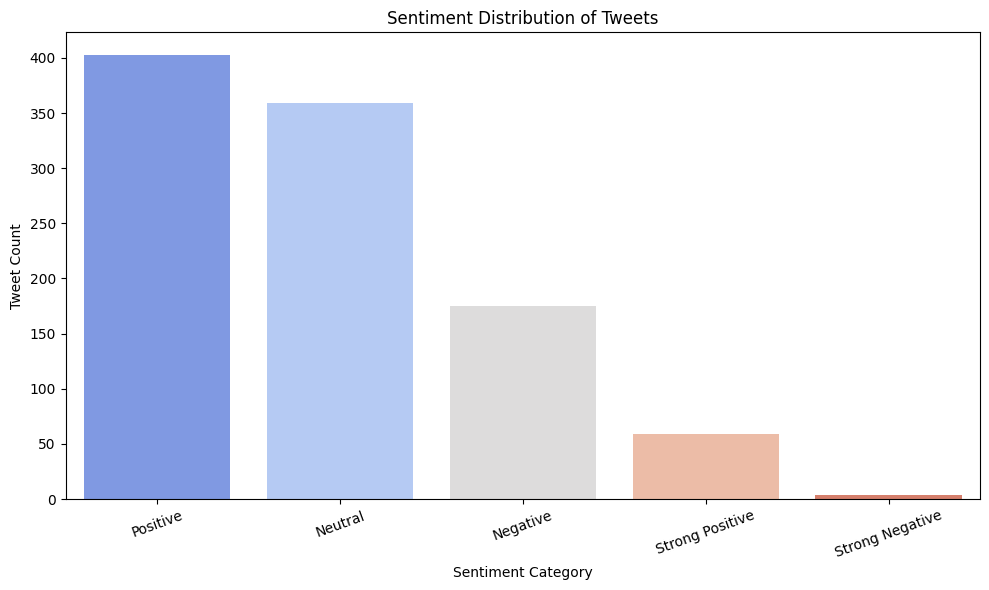

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Load tweets from CSV
file_path = "/mock_tweets_1000.csv"  # <- Replace with your file path
df = pd.read_csv(file_path)

# Make sure the column exists
if 'tweet' not in df.columns:
    raise Exception("CSV must contain a 'tweet' column.")

# Clean nulls
df.dropna(subset=['tweet'], inplace=True)

# Function to get sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.7:
        return 'Strong Positive'
    elif score >= 0.05:
        return 'Positive'
    elif score > -0.05:
        return 'Neutral'
    elif score > -0.7:
        return 'Negative'
    else:
        return 'Strong Negative'

# Apply sentiment analysis
df['Sentiment'] = df['tweet'].apply(get_sentiment)

# Show sample results
print("\n📋 Sample Analysis:")
print(df[['tweet', 'Sentiment']].head(10))

# Plot sentiment distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)
plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment Category")
plt.ylabel("Tweet Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
